# GSE248369 — Endocrine differentiation trajectory (Bio-Babel)

**Dataset:** E15.5 mouse embryonic pancreas, *Neurog3*-lineage (Tomato⁺) FACS-sorted cells (GSE248369), hand-QC'd and annotated (`data/analysis_input.h5ad`).
**Source study:** Davidson RK et al., *Diabetologia* 2024;67(10):2275-2288 — the SWI/SNF (BRG1/BRM) chromatin-remodelling complex in pancreatic endocrine development (doi:10.1007/s00125-024-06211-7).
**Genotypes:** `control`, `Brg1Δendo;Brm+/-` (dEndo, endocrine-progenitor BRG1 knockout), `DKO` (BRG1+BRM double knockout).

**Question.** How endocrine progenitors move through a *precursor* stage toward **alpha-** and **beta-**like cells, and whether that differentiation is perturbed across the three genotypes.

**Approach (Bio-Babel packages).**
1. Subset the endocrine differentiation population and build a **Monocle2 / DDRTree** trajectory from raw counts, rooted at the progenitor end; resolve the alpha and beta arms.
2. River plots of arm composition across pseudotime, per genotype.
3. Embryo-level test of genotype differences in alpha↔beta allocation.
4. **Monocle2 BEAM** at the alpha/beta branch point + branched-expression heatmap.
5. **tradeSeq** NB-GAMs along the alpha/beta lineages (smoothers, dynamic-gene heatmap) and a **condition-aware** fit with genotype (`conditionTest`).

All figures are rendered with **ggplot2-python** (+ pheatmap/grid_py for heatmaps) and written to `outputs/figures/`.

## 0. Parameters & random seed

In [1]:
# ---- Parameters (edit here) ----
SEED                 = 2024      # global RNG seed
DDRTREE_RANDOM_STATE = 2016      # Monocle2 reduce_dimension seed
N_KNOTS              = 6         # tradeSeq spline knots
N_BINS_HEATMAP       = 20        # pseudotime bins, per-arm marker heatmap
N_BINS_RIVER         = 12        # pseudotime bins, river plots
BEAM_QVAL            = 1e-4      # BEAM significance cutoff
TS_MAIN_PANEL        = 1500      # genes fit by the main tradeSeq GAM
TS_COND_PANEL        = 150       # genes fit by the condition-aware GAM (3-condition design is heavy)
MIN_CELLS_EXPRESSED  = 20        # gene detection filter for DE panels
import os
CORES = int(os.environ.get("ANALYSIS_CORES", "8"))   # set ANALYSIS_CORES to scale fits

DATA   = "data/analysis_input.h5ad"
OUTDIR = "outputs"; FIGDIR = "outputs/figures"
os.makedirs(FIGDIR, exist_ok=True)

import numpy as np, random
np.random.seed(SEED); random.seed(SEED)
print("params set | CORES =", CORES)

params set | CORES = 16


## 1. Imports & helper functions

In [2]:
import anndata as ad, monocle2py as m2, tradeseq as ts
import ggplot2_py as gg, pheatmap
from scipy import stats
import json
from IPython.display import Image, display
def show(path): display(Image(filename=path))

"""Shared params, palettes, marker panels, and helpers for the GSE248369 analysis."""
import numpy as np, pandas as pd, scipy.sparse as sp
import grid_py
from grid_py.renderer import CairoRenderer

SEED = 2024
DDRTREE_RANDOM_STATE = 2016   # monocle2 reduce_dimension seed

# endocrine differentiation population feeding the alpha/beta trajectory
# (delta + epsilon are distinct minor fates -> excluded so the alpha/beta bifurcation resolves cleanly)
TRAJ_POP = [
    "Neurog3-high endocrine progenitor",
    "Fev+ endocrine precursor",
    "endocrine intermediate",
    "alpha-like endocrine",
    "Pdx1+ beta-like endocrine",
    "mature beta-like endocrine",
]
ALL_ENDOCRINE = TRAJ_POP + ["delta-like endocrine", "ghrelin/epsilon-like endocrine"]

GENO_ORDER = ["control", "Brg1Δendo;Brm+/-", "DKO"]
GENO_SHORT = {"control": "control", "Brg1Δendo;Brm+/-": "dEndo", "DKO": "DKO"}
GENO_PAL = {"control": "#4daf4a", "Brg1Δendo;Brm+/-": "#377eb8", "DKO": "#e41a1c"}

ANNOT_PAL = {
    "Neurog3-high endocrine progenitor": "#6a3d9a",
    "Fev+ endocrine precursor": "#1f78b4",
    "endocrine intermediate": "#a6cee3",
    "alpha-like endocrine": "#e31a1c",
    "Pdx1+ beta-like endocrine": "#33a02c",
    "mature beta-like endocrine": "#b2df8a",
    "delta-like endocrine": "#ff7f00",
    "ghrelin/epsilon-like endocrine": "#fb9a99",
}
ARM_PAL = {"alpha": "#e31a1c", "beta": "#1b9e77", "trunk": "#888888",
           "progenitor/precursor": "#888888"}

# curated marker programs
PROG_MARKERS  = ["Neurog3", "Sox4", "Fev", "Chga", "Chgb", "Neurod1", "Pax6", "Insm1"]
ALPHA_MARKERS = ["Gcg", "Arx", "Irx1", "Irx2", "Ttr", "Pou3f4", "Peg3", "Isl1"]
BETA_MARKERS  = ["Ins1", "Ins2", "Pdx1", "Nkx6-1", "Pax4", "Iapp", "Mafa", "Slc2a2", "Ucn3", "Nnat"]
KEY_MARKERS   = ["Neurog3", "Fev", "Gcg", "Arx", "Ins2", "Pdx1", "Nkx6-1", "Mafa"]


def dense(X):
    return X.toarray() if sp.issparse(X) else np.asarray(X)


def gene_id(adata, sym):
    """gene_short_name -> var_name (Ensembl id); None if absent."""
    hits = adata.var_names[adata.var["gene_short_name"].astype(str).values == sym]
    return hits[0] if len(hits) else None


def present(adata, syms):
    return [s for s in syms if gene_id(adata, s) is not None]


def logcpm_col(adata, sym, layer="counts"):
    gid = gene_id(adata, sym)
    if gid is None:
        return None
    C = dense(adata.layers[layer])
    libs = C.sum(1, keepdims=True); libs[libs == 0] = 1
    j = adata.var_names.get_loc(gid)
    return np.log1p(C[:, j] / libs[:, 0] * 1e4)


def save_pheatmap(ph, filename, width=8, height=6, dpi=200):
    gt = ph.gtable if hasattr(ph, "gtable") else ph
    r = CairoRenderer(width=width, height=height, dpi=dpi, surface_type="image", bg="white")
    st = grid_py.get_state(); st.reset(); st.init_device(r)
    grid_py.grid_draw(gt); r.write_to_png(str(filename))
    return filename


def assign_arms(adata):
    """Data-driven: identify root state, alpha/beta terminal states, the alpha/beta
    branch_point, and per-cell lineage weights from the DDRTree centroid MST.
    Returns dict with keys: root_state, alpha_state, beta_state, branch_point,
    alpha_states, beta_states, and writes adata.obs['arm'] + obsm slots."""
    import igraph as ig, monocle2py as m2
    dd = adata.uns["monocle2"]["ddrtree"]
    edges = [tuple(map(int, e)) for e in np.asarray(dd["mst_edges"])]
    K = np.asarray(dd["K"]); n_cen = K.shape[1]
    cv = np.asarray(dd["closest_vertex"]).ravel().astype(int)
    G = ig.Graph(n=n_cen, edges=edges)
    deg = np.array(G.degree())
    leaves = np.where(deg == 1)[0]

    st = adata.obs["State"].astype(int).values
    pt = adata.obs["Pseudotime"].values
    gcg = logcpm_col(adata, "Gcg"); ins = logcpm_col(adata, "Ins2")
    # centroid -> dominant state, and per-centroid mean pseudotime / markers
    cdf = pd.DataFrame({"c": cv, "state": st, "pt": pt, "gcg": gcg, "ins": ins})
    cen_state = cdf.groupby("c")["state"].agg(lambda s: s.value_counts().index[0])
    cen_pt = cdf.groupby("c")["pt"].mean()
    # root centroid = leaf with lowest mean pseudotime
    leaf_pt = {int(l): cen_pt.get(l, np.inf) for l in leaves}
    root_c = min(leaf_pt, key=leaf_pt.get)
    # terminal leaves (exclude root); alpha tip = max Gcg, beta tip = max Ins
    cen_gcg = cdf.groupby("c")["gcg"].mean(); cen_ins = cdf.groupby("c")["ins"].mean()
    term = [int(l) for l in leaves if int(l) != root_c]
    alpha_c = max(term, key=lambda c: cen_gcg.get(c, -np.inf))
    beta_c  = max(term, key=lambda c: cen_ins.get(c, -np.inf))
    path_a = set(G.get_shortest_paths(root_c, to=alpha_c)[0])
    path_b = set(G.get_shortest_paths(root_c, to=beta_c)[0])
    # per-cell weights via nearest centroid; off-path cells -> closer tip
    dist_a = np.array(G.distances(source=alpha_c)[0])
    dist_b = np.array(G.distances(source=beta_c)[0])
    w_a = np.zeros(adata.n_obs); w_b = np.zeros(adata.n_obs)
    arm = np.empty(adata.n_obs, dtype=object)
    for i, c in enumerate(cv):
        ina, inb = c in path_a, c in path_b
        if ina and inb:   w_a[i] = w_b[i] = 1.0; arm[i] = "trunk"
        elif ina:         w_a[i] = 1.0;          arm[i] = "alpha"
        elif inb:         w_b[i] = 1.0;          arm[i] = "beta"
        else:  # off both main paths -> assign to closer tip
            if dist_a[c] <= dist_b[c]: w_a[i] = 1.0; arm[i] = "alpha"
            else:                      w_b[i] = 1.0; arm[i] = "beta"
    adata.obs["arm"] = pd.Categorical(arm, categories=["trunk", "alpha", "beta"])
    adata.obsm["pseudotime"] = np.column_stack([pt, pt])
    adata.obsm["cell_weights"] = np.column_stack([w_a, w_b])   # col0=alpha, col1=beta

    # which monocle2 branch_point separates alpha-state from beta-state?
    alpha_state = int(cen_state.get(alpha_c)); beta_state = int(cen_state.get(beta_c))
    root_state = int(cen_state.get(root_c))
    branch_point = None
    for bp in (1, 2, 3):
        try:
            b = m2.build_branch_cell_dataset(adata, branch_point=bp,
                                             progenitor_method="duplicate", stretch=False)
        except Exception:
            continue
        ctab = pd.crosstab(b.obs["State"].astype(int), b.obs["Branch"])
        if alpha_state in ctab.index and beta_state in ctab.index:
            # separated if alpha_state and beta_state have their mass in different branches
            abr = ctab.loc[alpha_state].idxmax(); bbr = ctab.loc[beta_state].idxmax()
            if abr != bbr:
                branch_point = bp; break
    return dict(root_state=root_state, alpha_state=alpha_state, beta_state=beta_state,
                branch_point=branch_point, alpha_c=int(alpha_c), beta_c=int(beta_c),
                n_alpha=int(w_a.sum()), n_beta=int(w_b.sum()),
                arm_counts=pd.Series(arm).value_counts().to_dict())

${ANALYSIS_WORKDIR}/environment/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load data & QC summary

The object is cells × genes with **raw integer counts** in `X`, gene symbols in `var['gene_short_name']`, and per-cell `genotype`, `sample` (embryo), `cluster`, and hand `broad_annotation`. Cells flagged `low_transcriptome_mapping_flag` are dropped.

In [3]:
adata = ad.read_h5ad(DATA)
print("shape:", adata.shape)
print("\ngenotype:\n", adata.obs["genotype"].value_counts().to_string())
print("\nbroad_annotation:\n", adata.obs["broad_annotation"].value_counts().to_string())
print("\nembryo (sample) x low_transcriptome_mapping_flag:")
print(pd.crosstab(adata.obs["sample"], adata.obs["low_transcriptome_mapping_flag"]).to_string())
# NOTE: the entire DKO 2 embryo (422 cells) is the low-quality-flagged batch -> removed by QC,
# leaving DKO with only 2 surviving embryos (a key power caveat, see report).

shape: (5196, 23308)

genotype:
 genotype
Brg1Δendo;Brm+/-    2849
control             1424
DKO                  923

broad_annotation:
 broad_annotation
Fev+ endocrine precursor             882
Pdx1+ beta-like endocrine            703
alpha-like endocrine                 614
Neurog3-high endocrine progenitor    477
ductal / epithelial                  451
endocrine intermediate               443
mesenchymal / fibroblast             350
ghrelin/epsilon-like endocrine       314
acinar / exocrine                    304
mature beta-like endocrine           304
delta-like endocrine                 189
endothelial                           69
immune / myeloid                      43
glial / neural crest-like             31
neuronal-like                         22

embryo (sample) x low_transcriptome_mapping_flag:
low_transcriptome_mapping_flag  False  True 
sample                                      
Control 1                         523      0
Control 2                         390      0


## 3. Subset the endocrine differentiation population

We keep the alpha/beta differentiation axis — *Neurog3*-high progenitor, *Fev*⁺ precursor, endocrine intermediate, alpha-like, and (Pdx1⁺ + mature) beta-like — and **exclude the delta and epsilon (ghrelin) fates**: they are distinct minor endocrine terminal states with strong unique hormones that, if included, fragment the 2-D DDRTree and blur the alpha/beta bifurcation. Low-quality cells are dropped.

In [4]:
mask = adata.obs["broad_annotation"].isin(TRAJ_POP) & (~adata.obs["low_transcriptome_mapping_flag"])
sub = adata[mask].copy()
sub.obs["broad_annotation"] = sub.obs["broad_annotation"].cat.remove_unused_categories()
sub.layers["counts"] = sub.X.copy()                     # raw counts for tradeSeq
sub.var["gene_short_name"] = sub.var["gene_short_name"].astype(str)
sub.obs["geno_short"] = pd.Categorical(sub.obs["genotype"].map(GENO_SHORT),
                                       categories=["control", "dEndo", "DKO"], ordered=True)
print("trajectory subset:", sub.shape)
print(sub.obs["broad_annotation"].value_counts().to_string())

trajectory subset: (3135, 23308)
broad_annotation
Fev+ endocrine precursor             819
Pdx1+ beta-like endocrine            640
alpha-like endocrine                 553
Neurog3-high endocrine progenitor    442
endocrine intermediate               390
mature beta-like endocrine           291


## 4. Monocle2 / DDRTree trajectory (raw counts), rooted at the progenitor end

Standard 9-step Monocle2 pipeline. **Ordering genes are supervised** (one-vs-rest markers across the endocrine annotations) so the DDRTree principal graph is oriented along *fate identity* rather than general maturation — this is what resolves the alpha vs beta arms. The root is chosen automatically as the *Neurog3*-high progenitor-enriched state.

In [5]:
# supervised one-vs-rest ordering genes on log1p-CPM
C = dense(sub.layers["counts"]); libs = C.sum(1, keepdims=True); libs[libs == 0] = 1
logcpm = np.log1p(C / libs * 1e4)
ncells = (C > 0).sum(0); sn = sub.var["gene_short_name"].values
tech = np.array([str(s).startswith(("mt-", "Rps", "Rpl", "Gm", "Rik", "Hb")) for s in sn])
keep = (ncells >= 10) & (~tech)
labels = sub.obs["broad_annotation"].values
ord_idx = set()
for grp in TRAJ_POP:
    score = np.where(keep, logcpm[labels == grp].mean(0) - logcpm[labels != grp].mean(0), -np.inf)
    ord_idx.update(int(i) for i in np.argsort(score)[::-1][:60])
curated = ["Neurog3","Fev","Chga","Chgb","Neurod1","Pax6","Isl1","Insm1","Runx1t1",
           "Arx","Gcg","Irx1","Irx2","Ttr","Pou3f4","Mafb","Peg3",
           "Ins1","Ins2","Pdx1","Nkx6-1","Nkx2-2","Pax4","Iapp","Mafa","Slc2a2","Ucn3","Cd24a"]
for c in curated:
    gid = gene_id(sub, c)
    if gid is not None: ord_idx.add(int(sub.var_names.get_loc(gid)))
ordering_genes = list(sub.var_names[sorted(ord_idx)])
print("supervised ordering genes:", len(ordering_genes))

m2.new_cell_dataset(sub)
m2.detect_genes(sub, min_expr=0.1)
m2.estimate_size_factors(sub)
m2.estimate_dispersions(sub)
m2.set_ordering_filter(sub, ordering_genes=ordering_genes)
m2.reduce_dimension(sub, max_components=2, reduction_method="DDRTree",
                    random_state=DDRTREE_RANDOM_STATE)
m2.order_cells(sub)                                    # seed States
# root state = most progenitor-enriched
sub.obs["_ng3"] = logcpm_col(sub, "Neurog3")
sp_ = sub.obs.groupby("State", observed=True).agg(
    n=("Pseudotime","size"), mean_pt=("Pseudotime","mean"), ng3=("_ng3","mean"),
    frac_prog=("broad_annotation", lambda s: (s == "Neurog3-high endocrine progenitor").mean()))
root_state = int(sp_.sort_values(["frac_prog","ng3"], ascending=False).index[0])
m2.order_cells(sub, root_state=root_state)             # anchor pseudotime at progenitor
print("root_state =", root_state)
print(pd.crosstab(sub.obs["State"], sub.obs["broad_annotation"]).to_string())

supervised ordering genes: 291


Removing 12708 outliers


root_state = 4
broad_annotation  Fev+ endocrine precursor  Neurog3-high endocrine progenitor  Pdx1+ beta-like endocrine  alpha-like endocrine  endocrine intermediate  mature beta-like endocrine
State                                                                                                                                                                             
1                                       47                                  0                         80                   494                     376                           2
2                                      228                                 11                         62                    28                       0                          27
3                                      114                                  4                          1                     1                      13                           4
4                                      422                                421             

### 4b. Trajectory figures — pseudotime, key markers, annotation, genotype

Saving 8 x 6 in image to outputs/figures/ab_pseudotime.png


Saving 9.5 x 6 in image to outputs/figures/ab_annotation.png


Saving 8.5 x 6 in image to outputs/figures/ab_genotype.png


Saving 8 x 6 in image to outputs/figures/ab_state.png


Saving 6.5 x 5 in image to outputs/figures/ab_marker_Neurog3.png


Saving 6.5 x 5 in image to outputs/figures/ab_marker_Fev.png


Saving 6.5 x 5 in image to outputs/figures/ab_marker_Gcg.png


Saving 6.5 x 5 in image to outputs/figures/ab_marker_Arx.png


Saving 6.5 x 5 in image to outputs/figures/ab_marker_Ins2.png


Saving 6.5 x 5 in image to outputs/figures/ab_marker_Pdx1.png


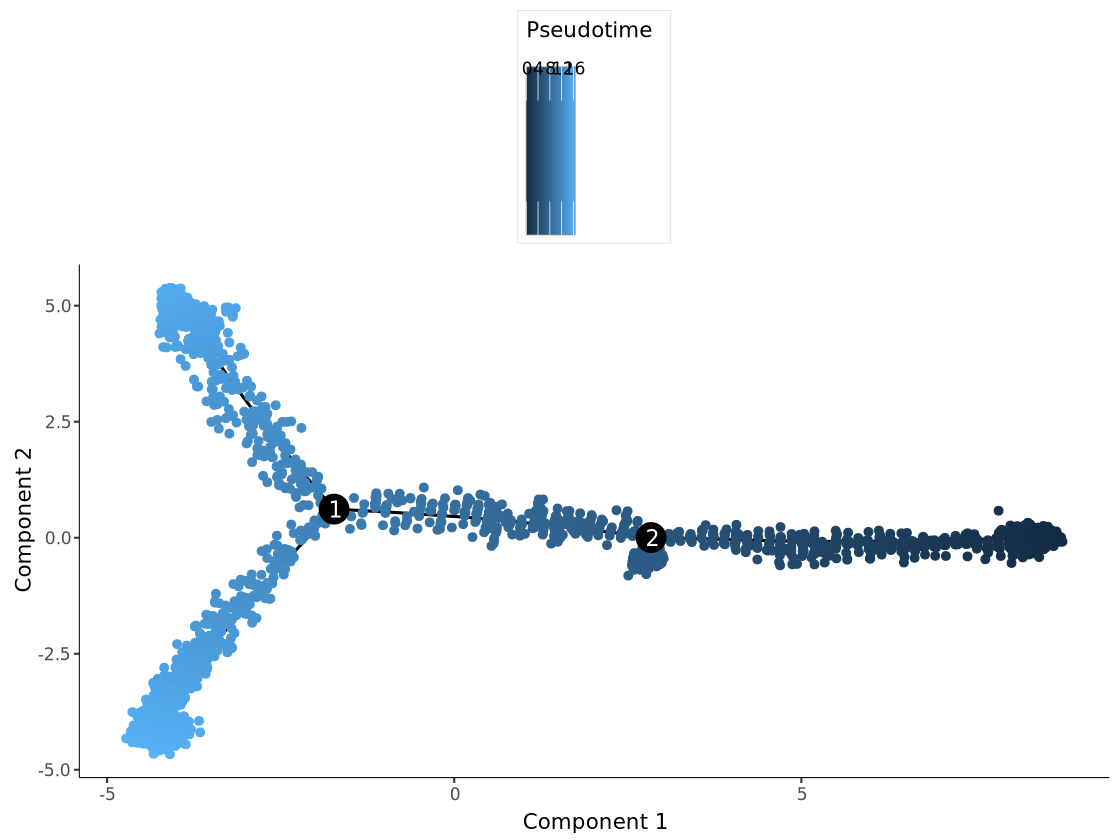

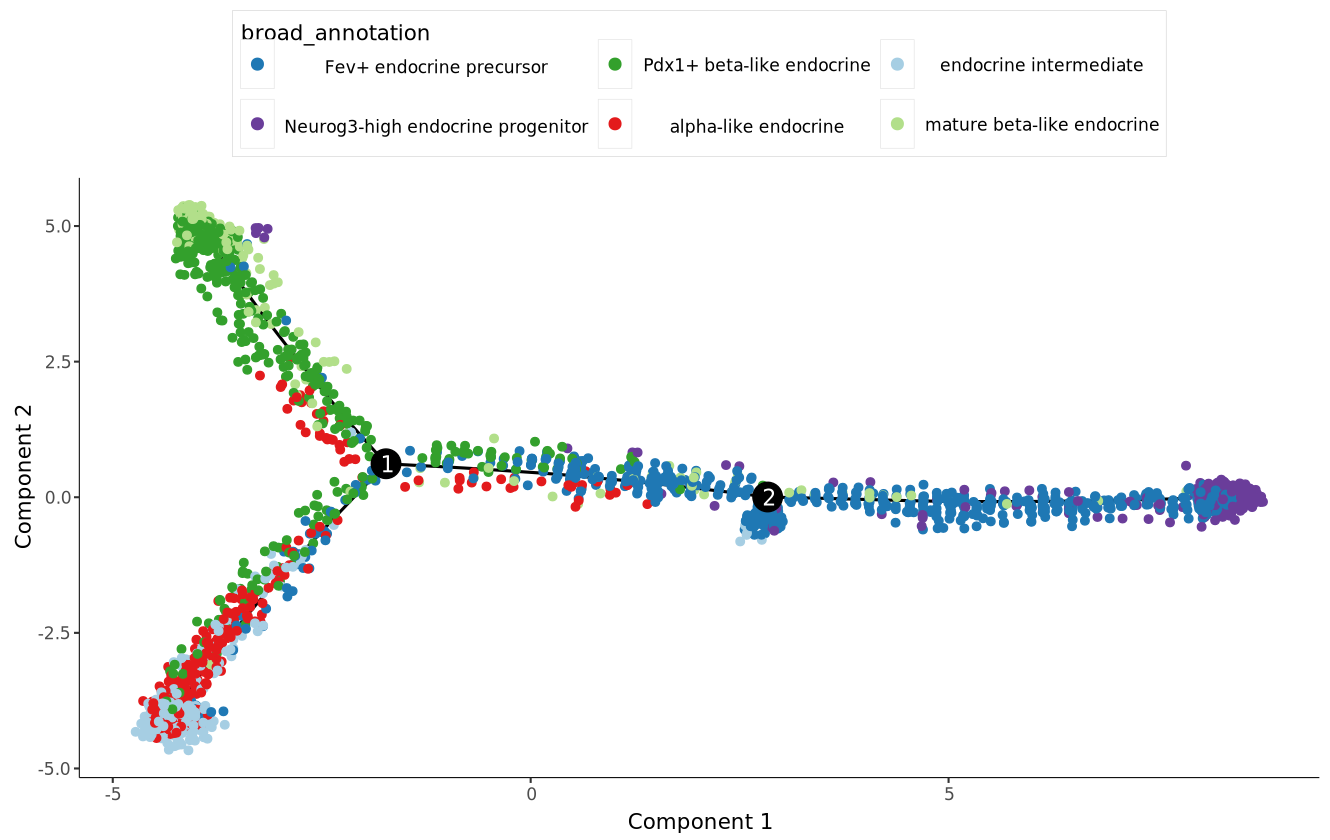

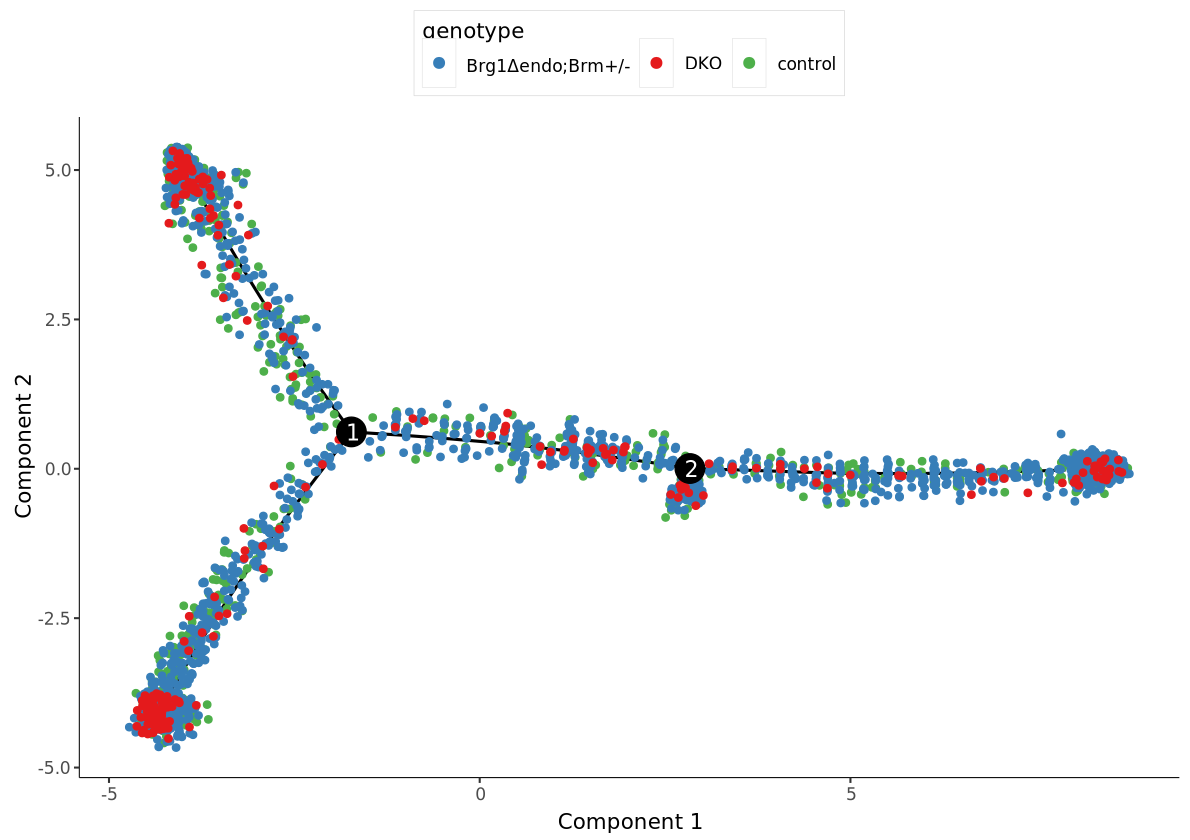

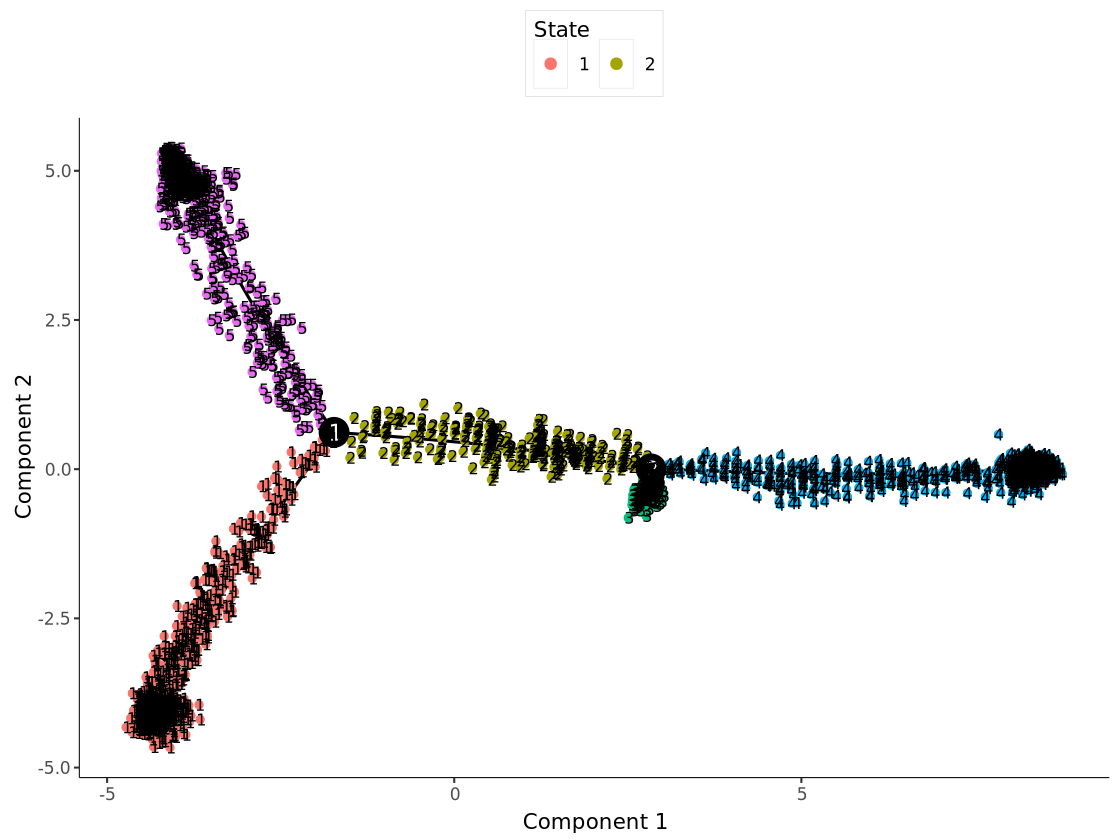

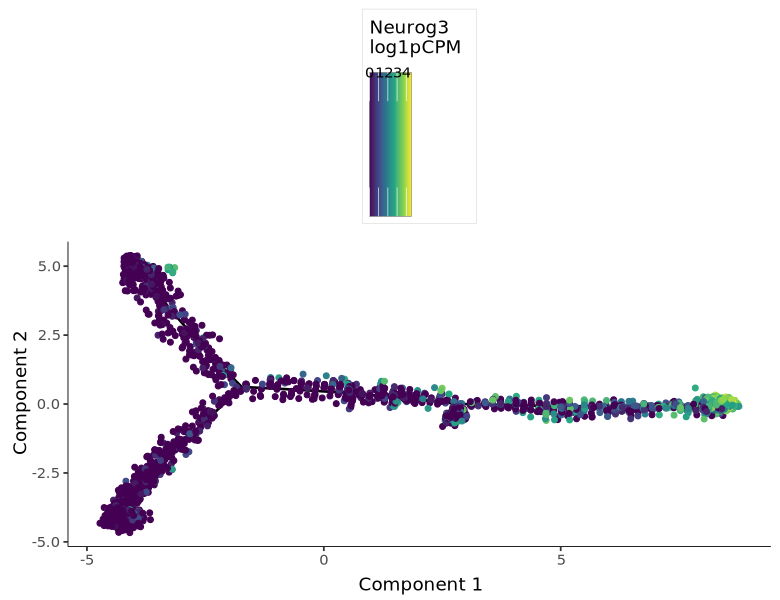

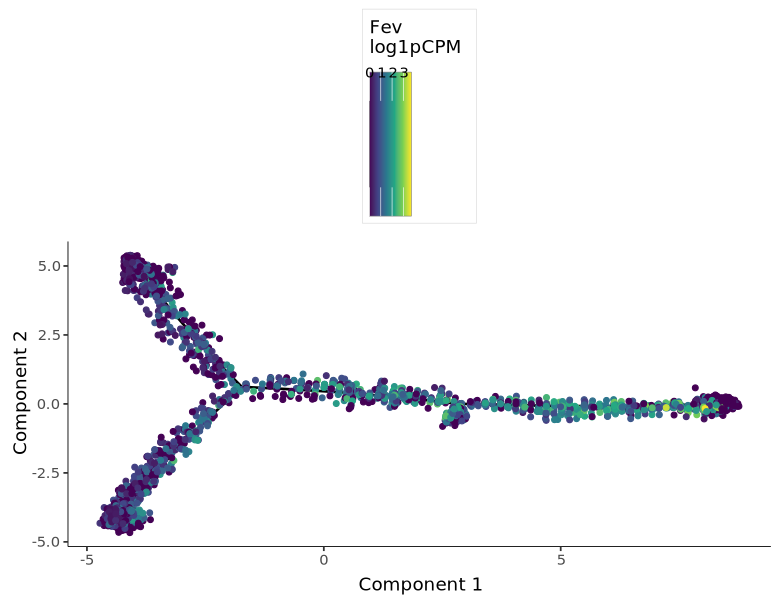

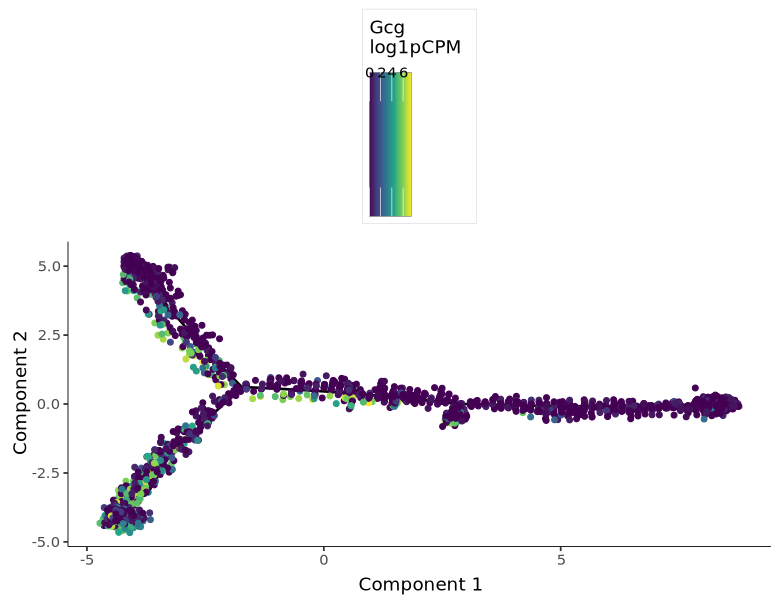

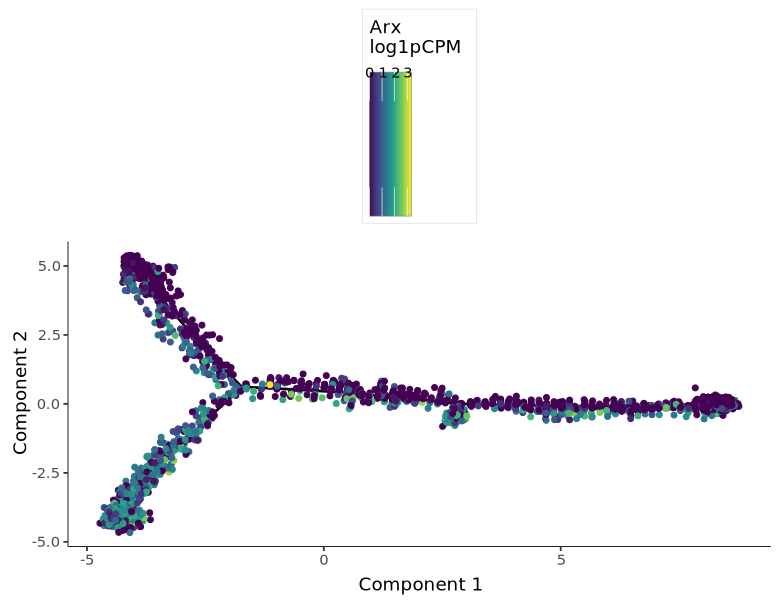

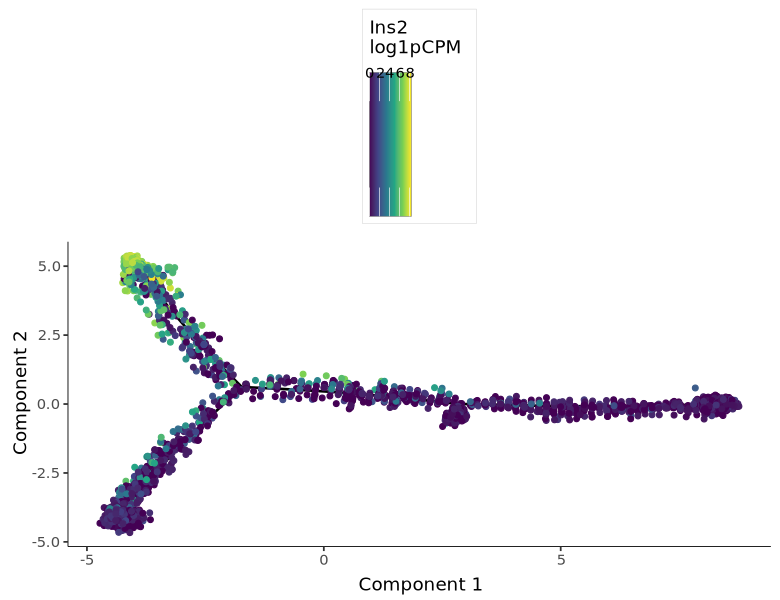

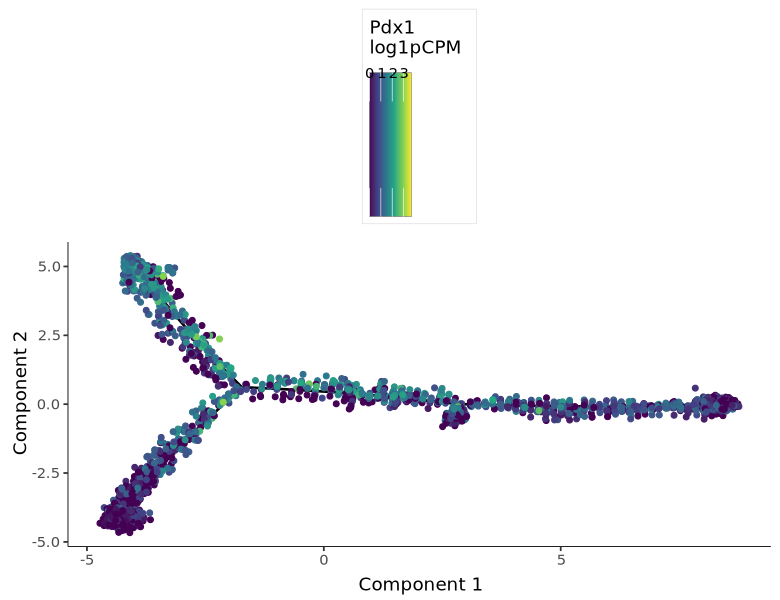

In [6]:
p = m2.plot_cell_trajectory(sub, color_by="Pseudotime", cell_size=1.2)
gg.ggsave(f"{FIGDIR}/ab_pseudotime.png", p, width=8, height=6, dpi=140)
p = m2.plot_cell_trajectory(sub, color_by="broad_annotation", cell_size=1.2) + gg.scale_color_manual(values=ANNOT_PAL)
gg.ggsave(f"{FIGDIR}/ab_annotation.png", p, width=9.5, height=6, dpi=140)
p = m2.plot_cell_trajectory(sub, color_by="genotype", cell_size=1.0) + gg.scale_color_manual(values=GENO_PAL)
gg.ggsave(f"{FIGDIR}/ab_genotype.png", p, width=8.5, height=6, dpi=140)
p = m2.plot_cell_trajectory(sub, color_by="State", show_state_number=True, cell_size=1.1)
gg.ggsave(f"{FIGDIR}/ab_state.png", p, width=8, height=6, dpi=140)
for mkr in ["Neurog3","Fev","Gcg","Arx","Ins2","Pdx1"]:
    sub.obs[f"m_{mkr}"] = logcpm_col(sub, mkr)
    pm = (m2.plot_cell_trajectory(sub, color_by=f"m_{mkr}", cell_size=0.9, show_branch_points=False)
          + gg.scale_color_viridis_c(name=f"{mkr}\nlog1pCPM"))
    gg.ggsave(f"{FIGDIR}/ab_marker_{mkr}.png", pm, width=6.5, height=5, dpi=120)
for f in ["ab_pseudotime","ab_annotation","ab_genotype","ab_state"]:
    show(f"{FIGDIR}/{f}.png")
for mkr in ["Neurog3","Fev","Gcg","Arx","Ins2","Pdx1"]:
    show(f"{FIGDIR}/ab_marker_{mkr}.png")

## 5. Resolve the alpha & beta arms + build the tradeSeq lineage bridge

`assign_arms` reads the DDRTree centroid MST: it picks the root leaf (lowest pseudotime), the alpha tip (max *Gcg*) and beta tip (max *Ins2*), traces root→tip paths, and labels each cell **trunk / alpha / beta**. Shared trunk cells get weight 1 in *both* lineages (slingshot convention). It also identifies which Monocle2 `branch_point` separates the alpha state from the beta state (for BEAM), and writes `obsm['pseudotime']` + `obsm['cell_weights']` for tradeSeq.

In [7]:
info = assign_arms(sub)
print(json.dumps(info, indent=1, default=int))
BP = info["branch_point"]
print("\narm x annotation:\n", pd.crosstab(sub.obs["arm"], sub.obs["broad_annotation"]).to_string())
print("\ncell_weights column sums (alpha, beta):", sub.obsm["cell_weights"].sum(0),
      "| pseudotime NaNs:", int(np.isnan(sub.obsm["pseudotime"]).sum()))

{
 "root_state": 4,
 "alpha_state": 1,
 "beta_state": 5,
 "branch_point": 2,
 "alpha_c": 96,
 "beta_c": 52,
 "n_alpha": 2210,
 "n_beta": 2138,
 "arm_counts": {
  "trunk": 1213,
  "alpha": 997,
  "beta": 925
 }
}

arm x annotation:
 broad_annotation  Fev+ endocrine precursor  Neurog3-high endocrine progenitor  Pdx1+ beta-like endocrine  alpha-like endocrine  endocrine intermediate  mature beta-like endocrine
arm                                                                                                                                                                               
trunk                                  652                                432                         62                    28                       0                          39
alpha                                   45                                  0                         80                   494                     376                           2
beta                                   122          

## 6. Per-arm marker-program heatmap

Curated **progenitor/precursor**, **alpha**, and **beta** programs, z-scored per gene, averaged over pseudotime bins within each arm. Each arm should light up its own terminal program.

Saving 9 x 6.5 in image to outputs/figures/marker_program_heatmap.png


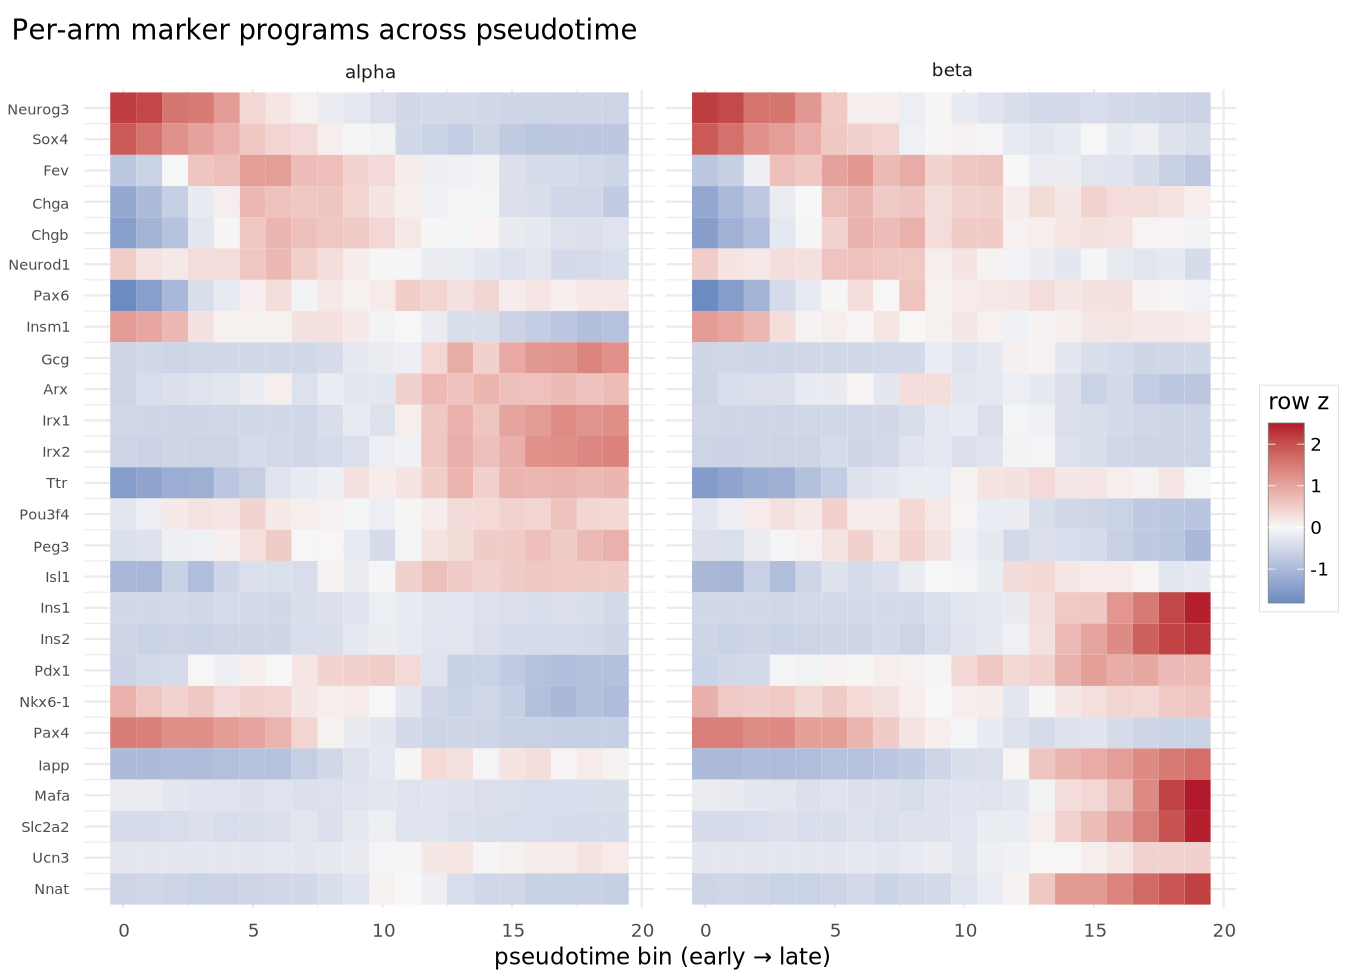

In [8]:
programs = [("progenitor/\nprecursor", present(sub, PROG_MARKERS)),
            ("alpha", present(sub, ALPHA_MARKERS)),
            ("beta", present(sub, BETA_MARKERS))]
genes = [g for _, gs in programs for g in gs]; prog_of = {g: p for p, gs in programs for g in gs}
mat = np.column_stack([logcpm_col(sub, g) for g in genes])
z = (mat - mat.mean(0)) / (mat.std(0) + 1e-9)
pt = sub.obs["Pseudotime"].values; arm = sub.obs["arm"].values
rows = []
for lineage, member in [("alpha", {"trunk","alpha"}), ("beta", {"trunk","beta"})]:
    m = np.array([a in member for a in arm]); ptl = pt[m]
    edges = np.quantile(ptl, np.linspace(0, 1, N_BINS_HEATMAP + 1)); edges[-1] += 1e-6
    b_idx = np.clip(np.digitize(ptl, edges) - 1, 0, N_BINS_HEATMAP - 1); zl = z[m]
    for b in range(N_BINS_HEATMAP):
        sel = b_idx == b
        if sel.sum() == 0: continue
        means = zl[sel].mean(0)
        for gi, g in enumerate(genes):
            rows.append((lineage, b, sub.var["gene_short_name"][gene_id(sub, g)], prog_of[g], means[gi]))
df = pd.DataFrame(rows, columns=["lineage","bin","gene","program","z"])
gene_order = [sub.var["gene_short_name"][gene_id(sub, g)] for g in genes][::-1]
df["gene"] = pd.Categorical(df["gene"], categories=gene_order, ordered=True)
df["lineage"] = pd.Categorical(df["lineage"], categories=["alpha","beta"], ordered=True)
df["z"] = df["z"].clip(-2.5, 2.5)
p = (gg.ggplot(df, gg.aes(x="bin", y="gene", fill="z")) + gg.geom_tile()
     + gg.facet_wrap("lineage", nrow=1)
     + gg.scale_fill_gradient2(low="#2166ac", mid="#f7f7f7", high="#b2182b", midpoint=0, name="row z")
     + gg.labs(title="Per-arm marker programs across pseudotime",
               x="pseudotime bin (early → late)", y=None)
     + gg.theme_minimal() + gg.theme(axis_text_y=gg.element_text(size=7)))
gg.ggsave(f"{FIGDIR}/marker_program_heatmap.png", p, width=9, height=6.5, dpi=150)
show(f"{FIGDIR}/marker_program_heatmap.png")

## 7. River plots — arm composition across pseudotime, by genotype

Saving 11 x 4 in image to outputs/figures/river_arm_composition.png


Saving 11 x 4 in image to outputs/figures/river_alpha_beta_committed.png


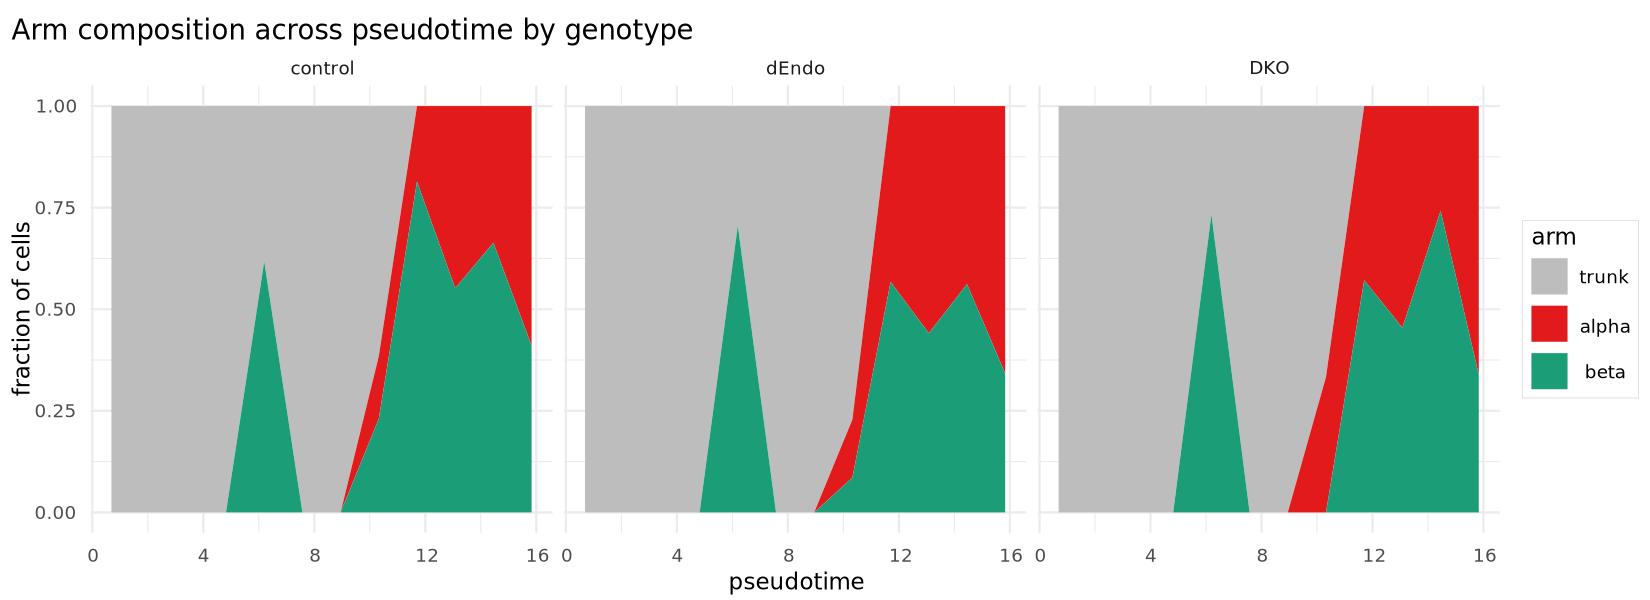

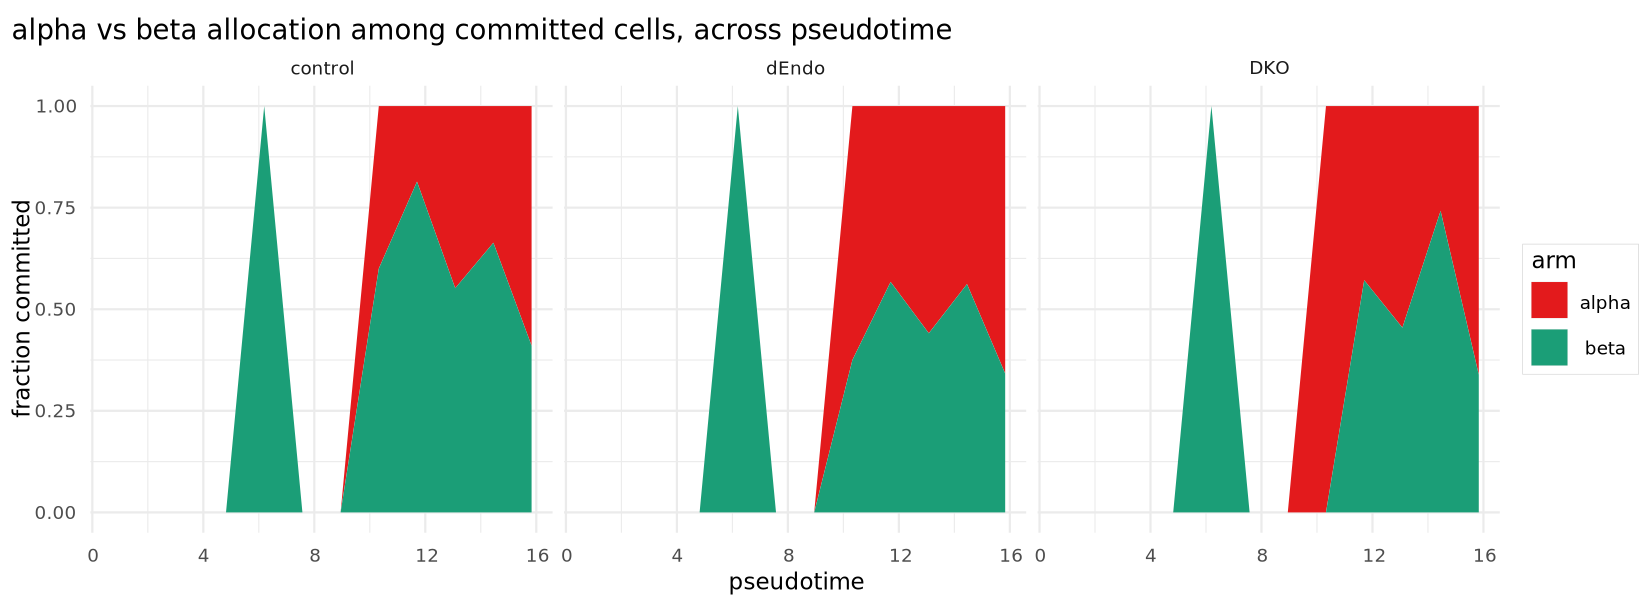

In [9]:
pt = sub.obs["Pseudotime"].values
edges = np.linspace(pt.min(), pt.max(), N_BINS_RIVER + 1); edges[-1] += 1e-6
sub.obs["ptbin"] = np.clip(np.digitize(pt, edges) - 1, 0, N_BINS_RIVER - 1)
midpts = (edges[:-1] + edges[1:]) / 2
def composition_grid(obs, arms):
    idx = pd.MultiIndex.from_product([["control","dEndo","DKO"], range(N_BINS_RIVER), arms],
                                     names=["geno_short","ptbin","arm"])
    g = (obs.groupby(["geno_short","ptbin","arm"], observed=True).size()
         .reindex(idx, fill_value=0).rename("n").reset_index())
    g["pt"] = midpts[g["ptbin"].values]
    g["geno_short"] = pd.Categorical(g["geno_short"], categories=["control","dEndo","DKO"], ordered=True)
    g["arm"] = pd.Categorical(g["arm"], categories=arms, ordered=True)
    return g
g = composition_grid(sub.obs, ["trunk","alpha","beta"])
p1 = (gg.ggplot(g, gg.aes(x="pt", y="n", fill="arm")) + gg.geom_area(stat="identity", position="fill")
      + gg.facet_wrap("geno_short", nrow=1)
      + gg.scale_fill_manual(values={"trunk":"#bdbdbd","alpha":"#e31a1c","beta":"#1b9e77"})
      + gg.labs(title="Arm composition across pseudotime by genotype",
                x="pseudotime", y="fraction of cells", fill="arm") + gg.theme_minimal())
gg.ggsave(f"{FIGDIR}/river_arm_composition.png", p1, width=11, height=4, dpi=150)
c = sub.obs[sub.obs["arm"].isin(["alpha","beta"])].copy()
gc = composition_grid(c, ["alpha","beta"])
p2 = (gg.ggplot(gc, gg.aes(x="pt", y="n", fill="arm")) + gg.geom_area(stat="identity", position="fill")
      + gg.facet_wrap("geno_short", nrow=1)
      + gg.scale_fill_manual(values={"alpha":"#e31a1c","beta":"#1b9e77"})
      + gg.labs(title="alpha vs beta allocation among committed cells, across pseudotime",
                x="pseudotime", y="fraction committed", fill="arm") + gg.theme_minimal())
gg.ggsave(f"{FIGDIR}/river_alpha_beta_committed.png", p2, width=11, height=4, dpi=150)
show(f"{FIGDIR}/river_arm_composition.png"); show(f"{FIGDIR}/river_alpha_beta_committed.png")

## 8. Embryo-level test: does genotype change alpha↔beta allocation?

The biological replicate is the **embryo**, so we test per-embryo beta fractions (committed cells) across genotypes with Kruskal-Wallis (+ pairwise Mann-Whitney). A cell-level chi-square is shown *only for contrast* — it is pseudoreplicated and not the inferential test.

Saving 6.5 x 5 in image to outputs/figures/allocation_per_embryo.png


              geno  n_alpha  n_beta    n  beta_frac
sample                                             
Control 1  control      101     131  232   0.564655
Control 2  control      121     104  225   0.462222
Control 3  control       84     112  196   0.571429
dEndo 1      dEndo       43      17   60   0.283333
dEndo 2      dEndo       68      91  159   0.572327
dEndo 3      dEndo      295     245  540   0.453704
dEndo 4      dEndo      187     141  328   0.429878
DKO 1          DKO       54      44   98   0.448980
DKO 3          DKO       44      40   84   0.476190

Kruskal-Wallis (embryo-level beta_frac ~ genotype): H=1.711, p=0.4250
  MWU control vs dEndo: p=0.400
  MWU control vs DKO: p=0.400
  MWU dEndo vs DKO: p=0.800

[pseudoreplicated, context only] cell-level chi-square: chi2=9.98, p=0.00679


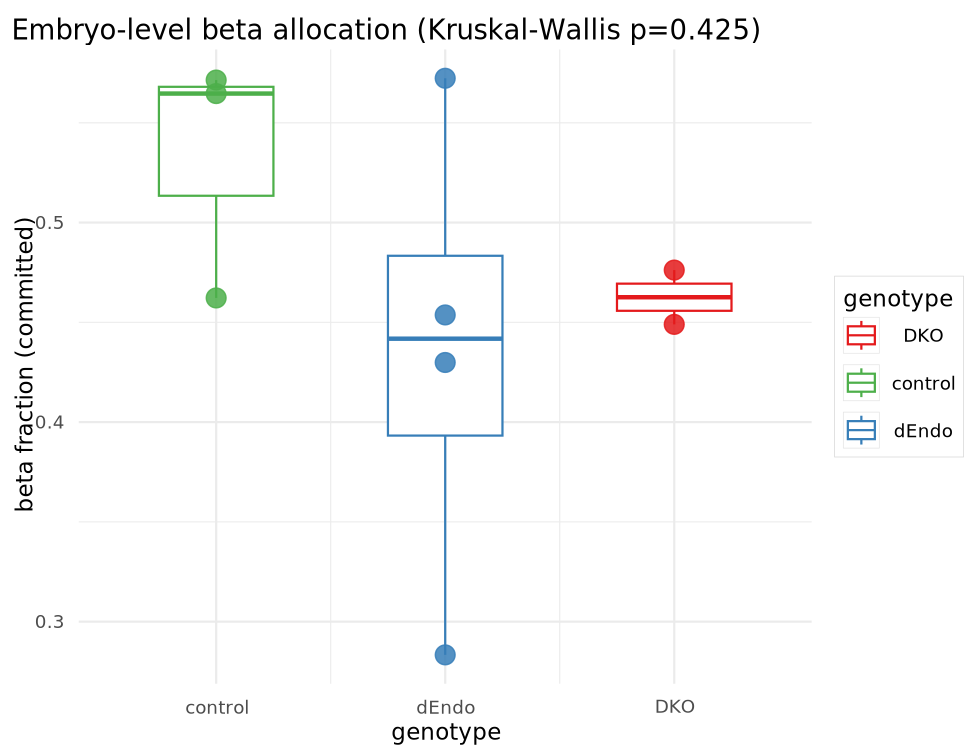

In [10]:
c = sub.obs[sub.obs["arm"].isin(["alpha","beta"])].copy()
emb = (c.groupby("sample", observed=True)
       .agg(geno=("geno_short","first"),
            n_alpha=("arm", lambda s: (s == "alpha").sum()),
            n_beta =("arm", lambda s: (s == "beta").sum())))
emb["n"] = emb["n_alpha"] + emb["n_beta"]; emb["beta_frac"] = emb["n_beta"] / emb["n"]
emb["geno"] = pd.Categorical(emb["geno"], categories=["control","dEndo","DKO"], ordered=True)
emb = emb.sort_values("geno"); print(emb.to_string())
groups = [emb.loc[emb["geno"] == g, "beta_frac"].values for g in ["control","dEndo","DKO"]]
H, p_kw = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (embryo-level beta_frac ~ genotype): H={H:.3f}, p={p_kw:.4f}")
for a, b in [("control","dEndo"), ("control","DKO"), ("dEndo","DKO")]:
    U, pu = stats.mannwhitneyu(emb.loc[emb.geno==a,"beta_frac"], emb.loc[emb.geno==b,"beta_frac"])
    print(f"  MWU {a} vs {b}: p={pu:.3f}")
ct = pd.crosstab(c["geno_short"], c["arm"]); chi2, p_chi, _, _ = stats.chi2_contingency(ct.values)
print(f"\n[pseudoreplicated, context only] cell-level chi-square: chi2={chi2:.2f}, p={p_chi:.3g}")
emb.to_csv(f"{OUTDIR}/allocation_per_embryo.csv")
p = (gg.ggplot(emb.reset_index(), gg.aes(x="geno", y="beta_frac", color="geno"))
     + gg.geom_boxplot(outlier_alpha=0, width=0.5) + gg.geom_point(size=3, alpha=0.85)
     + gg.scale_color_manual(values={"control":"#4daf4a","dEndo":"#377eb8","DKO":"#e41a1c"})
     + gg.labs(title=f"Embryo-level beta allocation (Kruskal-Wallis p={p_kw:.3f})",
               x="genotype", y="beta fraction (committed)", color="genotype") + gg.theme_minimal())
gg.ggsave(f"{FIGDIR}/allocation_per_embryo.png", p, width=6.5, height=5, dpi=150)
show(f"{FIGDIR}/allocation_per_embryo.png")

## 9. Monocle2 BEAM at the alpha/beta branch point

BEAM tests, per gene, whether expression **diverges between the two fates** as a function of pseudotime (branch × spline interaction). The branched heatmap stitches the pre-branch trunk to the two fate arms.

BEAM branch-dependent genes (qval<0.0001): 2850 / 16888
                   gene_short_name  qval
gene_id                                 
ENSMUSG00000041245            Wnk3   0.0
ENSMUSG00000067786            Nnat   0.0
ENSMUSG00000031170         Slc38a5   0.0
ENSMUSG00000052572            Dlg2   0.0
ENSMUSG00000057069          Ero1lb   0.0
ENSMUSG00000047591            Mafa   0.0
ENSMUSG00000061808             Ttr   0.0
ENSMUSG00000031099         Smarca1   0.0
ENSMUSG00000022490         Ppp1r1a   0.0
ENSMUSG00000054728         Phactr1   0.0
ENSMUSG00000029467          Atp2a2   0.0
ENSMUSG00000032776           Mctp2   0.0
ENSMUSG00000029673           Auts2   0.0
ENSMUSG00000061601            Pclo   0.0
ENSMUSG00000040856            Dlk1   0.0
ENSMUSG00000035804            Ins1   0.0
ENSMUSG00000027690          Slc2a2   0.0
ENSMUSG00000078974          Sec61g   0.0
ENSMUSG00000017311             Pyy   0.0
ENSMUSG00000017316             Ppy   0.0


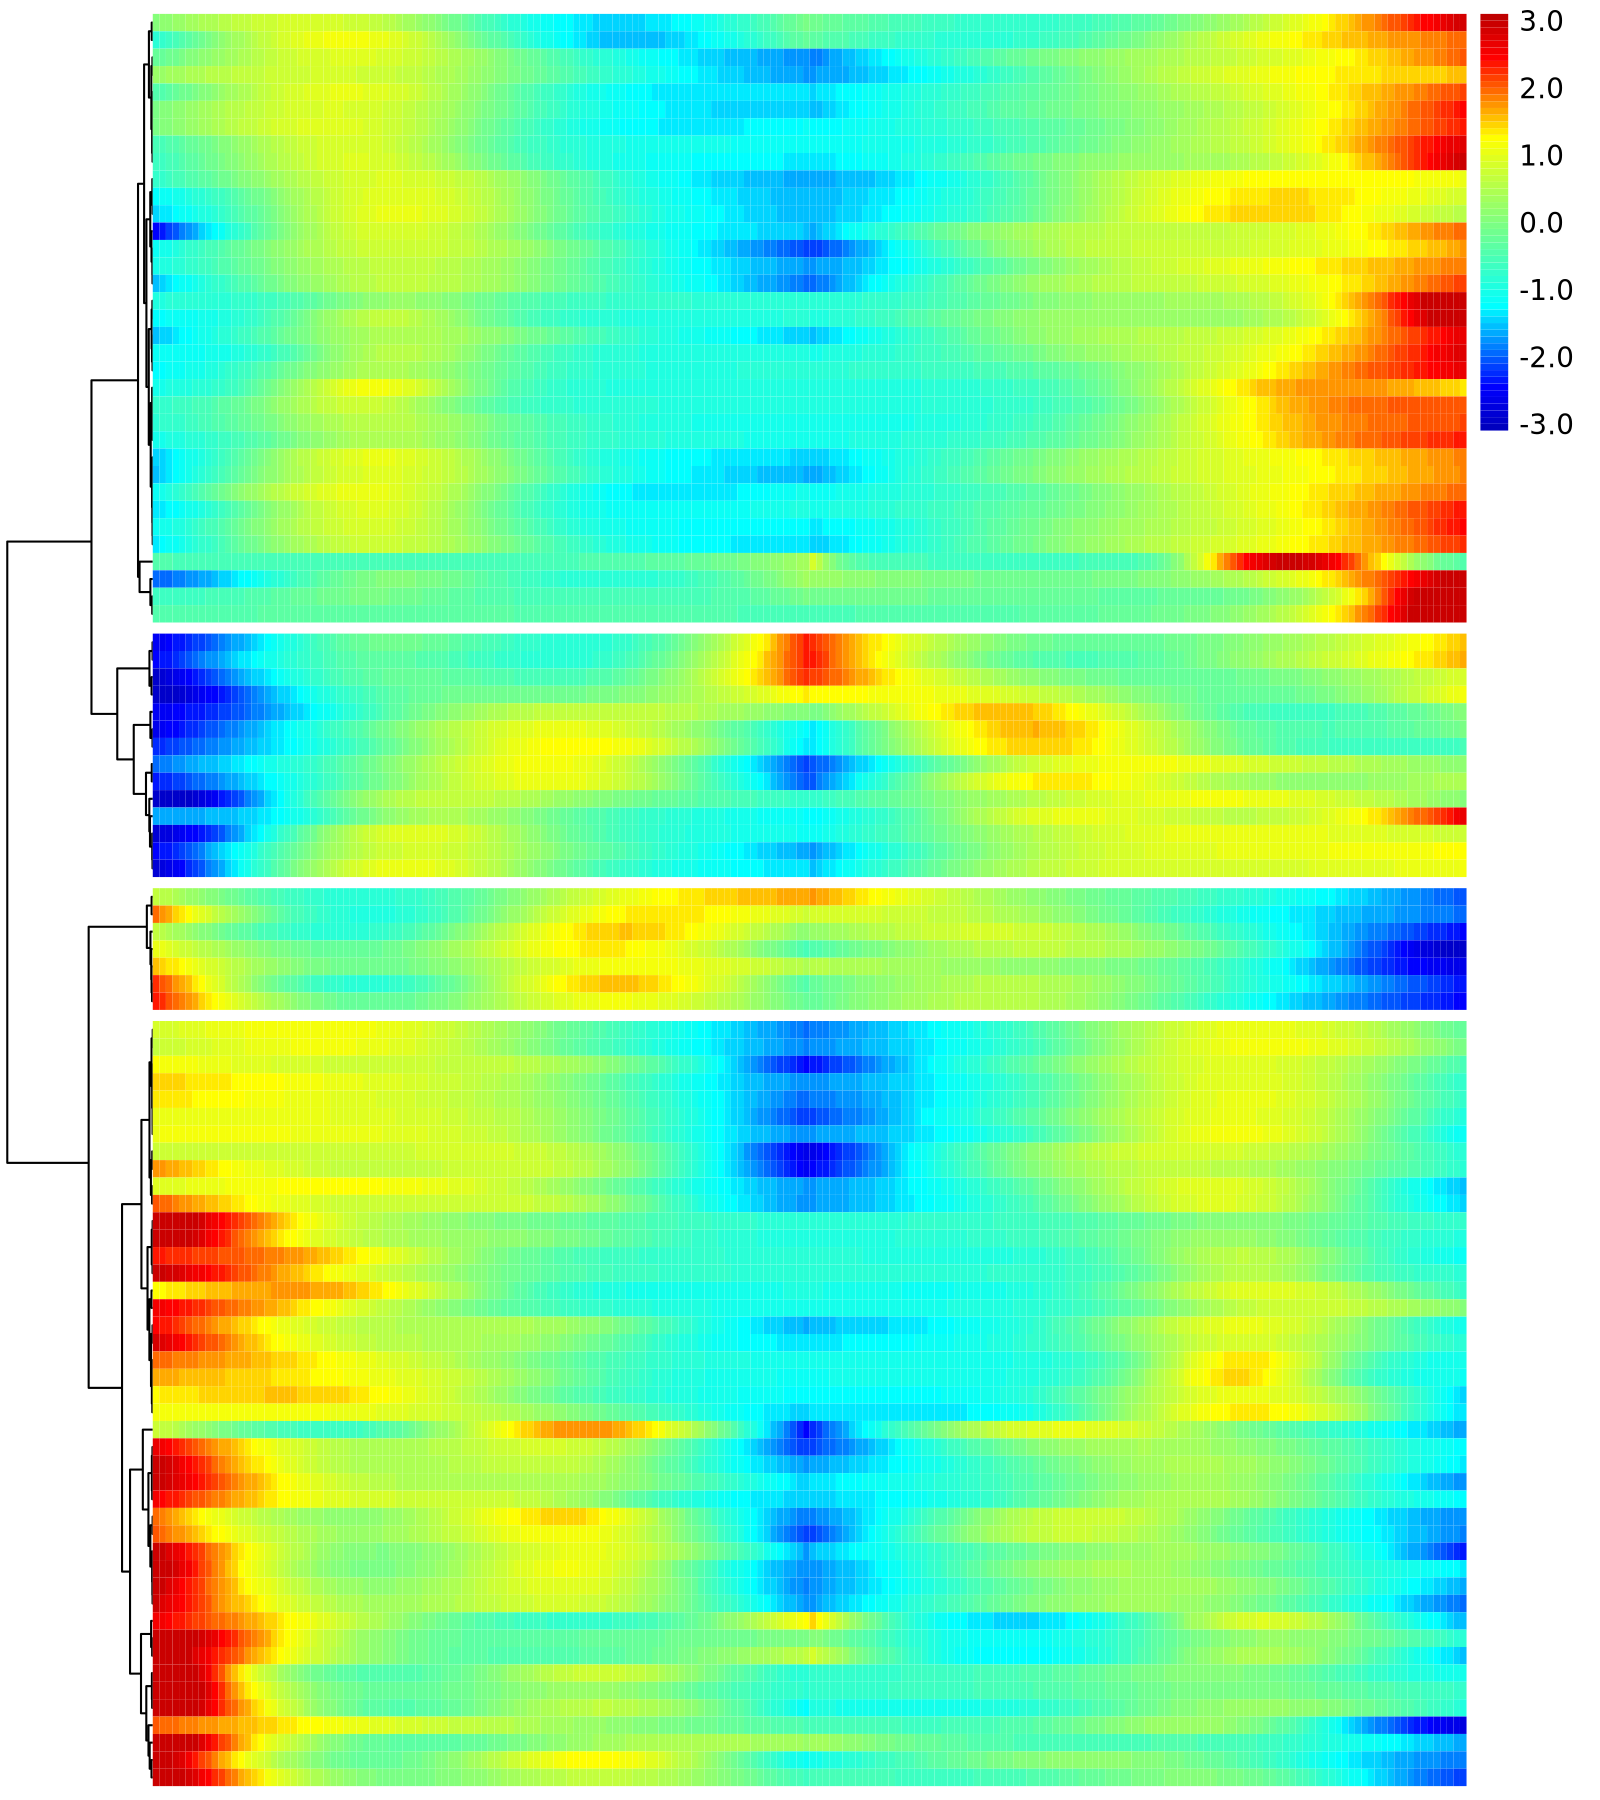

In [11]:
expr = sub.var["num_cells_expressed"] >= MIN_CELLS_EXPRESSED
beam_res = m2.beam(sub[:, expr].copy(), branch_point=BP,
                   full_model_formula_str="~sm.ns(Pseudotime, df=3)*Branch",
                   reduced_model_formula_str="~sm.ns(Pseudotime, df=3)", cores=CORES).sort_values("qval")
beam_res.to_csv(f"{OUTDIR}/beam_alpha_beta.csv")
sig = beam_res[beam_res["qval"] < BEAM_QVAL]
print(f"BEAM branch-dependent genes (qval<{BEAM_QVAL}): {len(sig)} / {len(beam_res)}")
print(sig.head(20)[["gene_short_name","qval"]].to_string())
top_ids = list(sig.index[:100])
d = m2.plot_genes_branched_heatmap(sub[:, top_ids], branch_point=BP, num_clusters=4,
        branch_labels=("beta","alpha"), use_gene_short_name=True, show_rownames=False,
        return_heatmap=True)
save_pheatmap(d["ph"], f"{FIGDIR}/beam_branched_heatmap.png", 8, 9, 200)
mk = [gene_id(sub, g) for g in (ALPHA_MARKERS + BETA_MARKERS)]
mk = [g for g in mk if g is not None and g in set(beam_res.index[beam_res["qval"] < 0.05])]
d2 = m2.plot_genes_branched_heatmap(sub[:, mk], branch_point=BP, num_clusters=2,
        branch_labels=("beta","alpha"), use_gene_short_name=True, show_rownames=True, return_heatmap=True)
save_pheatmap(d2["ph"], f"{FIGDIR}/beam_branched_markers.png", 8, 6, 200)
show(f"{FIGDIR}/beam_branched_heatmap.png")

## 10. tradeSeq — NB-GAMs along the alpha & beta lineages

`fit_gam` fits a per-gene negative-binomial GAM along each lineage using the pseudotime + cell-weight bridge built in §5. We then run the Wald battery (within-lineage `associationTest`/`startVsEndTest`; between-lineage `diffEndTest`/`patternTest`), plot smoothers for key markers, and build a dynamic-gene heatmap of fitted smoothers.

main tradeSeq panel: 1116


Saving 12 x 3 in image to outputs/figures/tradeseq_evaluatek.png


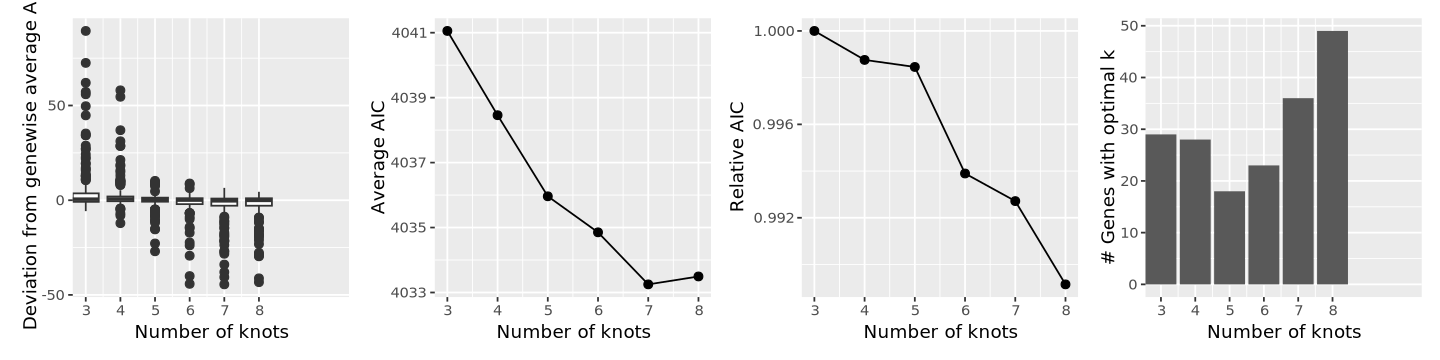

converged: 1116 / 1116


diff_end (endpoint alpha vs beta) top: ['Ins1', 'Gcg', 'Ins2', 'Sec61b', 'Ero1lb', 'C2cd4b', 'Nnat', 'Smarca1', 'Gng12', 'Sytl4', 'Dlg2', 'Ghrl']
pattern (transient) top: ['Ins1', 'Gcg', 'Ins2', 'Nnat', 'Gng12', 'Gast', 'Sec61b', 'Smarca1', 'Atp2a2', 'Hadh', 'Pdx1', 'Ghrl']


In [12]:
# work on a gene-symbol-keyed copy so every tradeSeq result/figure is labelled by marker name
# (lineage 1 = alpha, lineage 2 = beta, from the cell_weights column order in assign_arms)
subm = sub.copy()
subm.var["ensembl"] = subm.var_names
subm.var_names = pd.Index(subm.var["gene_short_name"].astype(str)); subm.var_names_make_unique()

sym_all = subm.var_names
tech = np.array([str(s).startswith(("mt-","Rps","Rpl","Gm","Rik","Hb","Hba","Hbb")) for s in sym_all])
expr = (subm.var["num_cells_expressed"].values >= MIN_CELLS_EXPRESSED) & (~tech)
C = dense(subm.layers["counts"]); libs = C.sum(1, keepdims=True); libs[libs==0]=1
var = np.where(expr, np.log1p(C/libs*1e4).var(0), -np.inf)
topvar = list(sym_all[np.argsort(var)[::-1][:400]])
beam_sym = {sub.var["gene_short_name"][g] for g in beam_res.index[:1000]}
beam_top = [g for g in sym_all[expr] if g in beam_sym]
markers = [g for g in (PROG_MARKERS+ALPHA_MARKERS+BETA_MARKERS) if g in set(sym_all)]
main_panel = list(dict.fromkeys(beam_top + topvar + markers))[:TS_MAIN_PANEL]
print("main tradeSeq panel:", len(main_panel))

# evaluate_k diagnostic
try:
    aic = ts.evaluate_k2(subm, k_range=range(3, 9), n_genes=200, plot=False, verbose=False)
    gg.ggsave(f"{FIGDIR}/tradeseq_evaluatek.png", ts.plot_evaluatek_results(aic), width=12, height=3, dpi=120)
    show(f"{FIGDIR}/tradeseq_evaluatek.png")
except Exception as e:
    print("evaluate_k skipped:", repr(e))

ts.fit_gam(subm, genes=main_panel, n_knots=N_KNOTS, parallel=True, n_jobs=CORES, verbose=False)
print("converged:", int(subm.var["tradeseq_converged"].sum()), "/", len(main_panel))
assoc = ts.association_test(subm).sort_values("waldStat", ascending=False)
sve   = ts.start_vs_end_test(subm).sort_values("waldStat", ascending=False)
dend  = ts.diff_end_test(subm).sort_values("waldStat", ascending=False)
patt  = ts.pattern_test(subm).sort_values("waldStat", ascending=False)
for name, dfr in [("association",assoc),("start_vs_end",sve),("diff_end",dend),("pattern",patt)]:
    dfr.to_csv(f"{OUTDIR}/tradeseq_{name}.csv")
print("diff_end (endpoint alpha vs beta) top:", list(dend.index[:12]))
print("pattern (transient) top:", list(patt.index[:12]))

### 10b. Smoothers for key markers & dynamic-gene heatmap

Saving 11 x 6 in image to outputs/figures/tradeseq_smoothers_markers.png


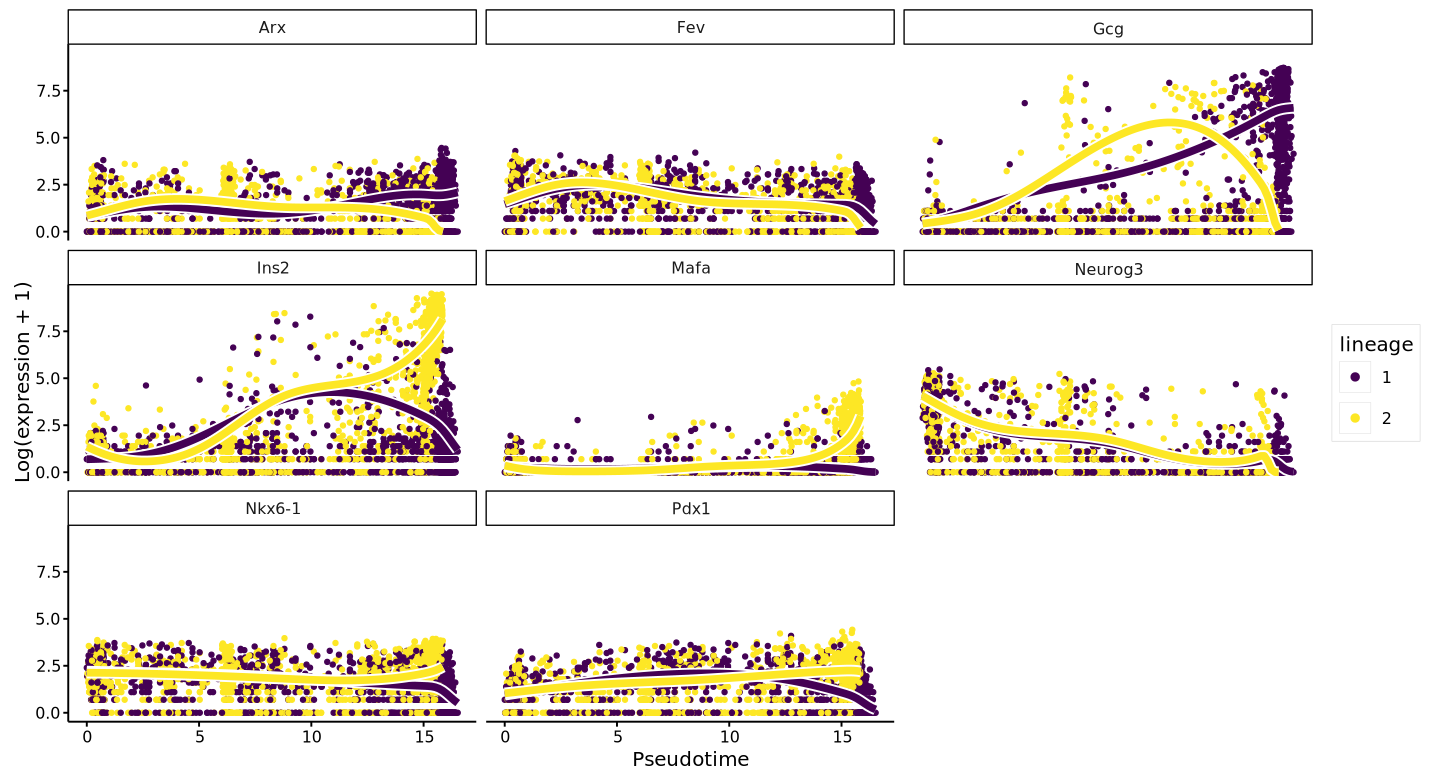

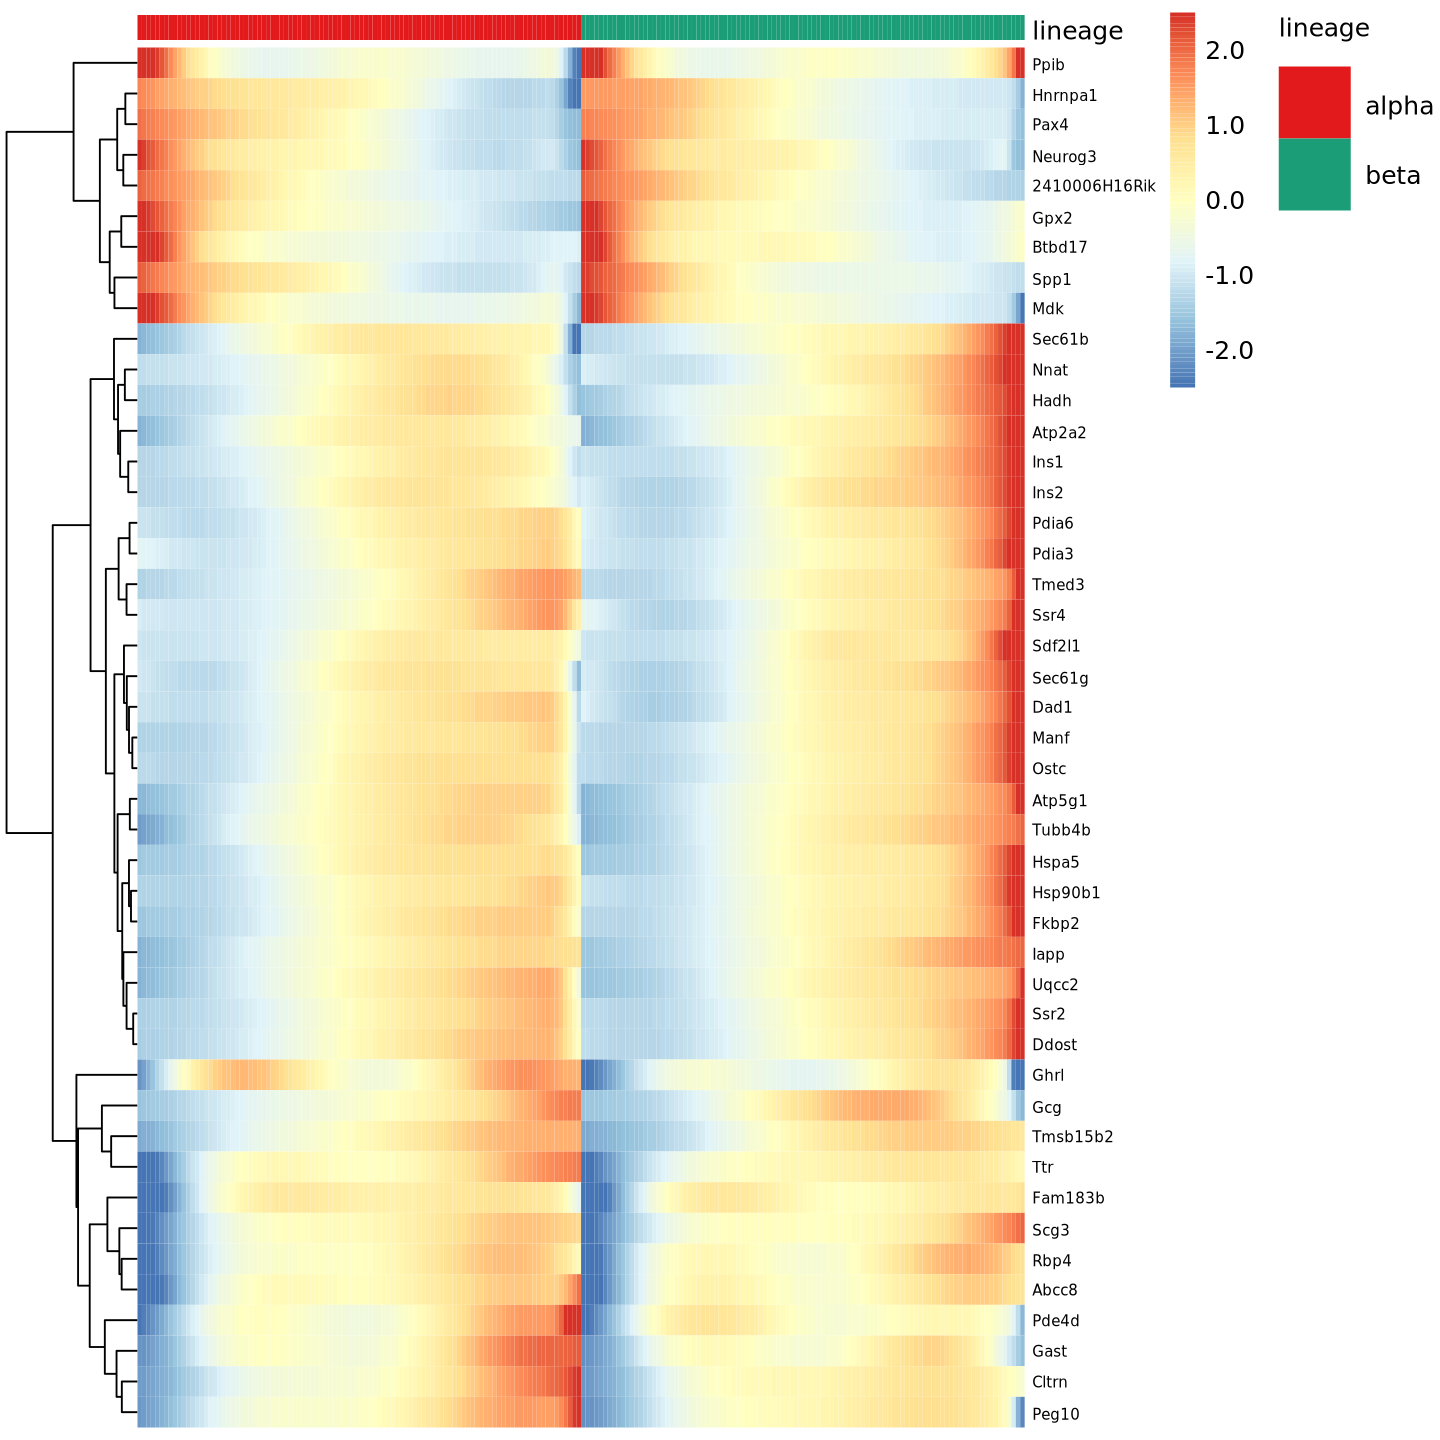

In [13]:
km = [g for g in KEY_MARKERS if g in set(main_panel)]
p = ts.plot_smoothers(subm, gene=km)   # lineage 1 = alpha, lineage 2 = beta
gg.ggsave(f"{FIGDIR}/tradeseq_smoothers_markers.png", p, width=11, height=6, dpi=130)
show(f"{FIGDIR}/tradeseq_smoothers_markers.png")

topg = list(assoc.index[:45])
ps = ts.predict_smooth(subm, gene=topg, n_points=100, tidy=True)
mat = ps.pivot_table(index="gene", columns=["lineage","time"], values="yhat").reindex(topg)
ann_col = pd.DataFrame({"lineage": ["alpha" if l == 1 else "beta" for l, _ in mat.columns]},
                       index=[f"c{i}" for i in range(mat.shape[1])])
# log1p to compress dynamic range, then per-gene z-score, clipped -> readable heatmap
lm = np.log1p(mat.values)
zz = np.clip((lm - lm.mean(1, keepdims=True)) / (lm.std(1, keepdims=True) + 1e-9), -2.5, 2.5)
mm = pd.DataFrame(zz, index=mat.index, columns=ann_col.index)
ph = pheatmap.pheatmap(mm, scale="none", cluster_cols=False, cluster_rows=True,
                       show_colnames=False, show_rownames=True, annotation_col=ann_col,
                       annotation_colors={"lineage": {"alpha":"#e31a1c","beta":"#1b9e77"}},
                       fontsize_row=6, silent=True)
save_pheatmap(ph, f"{FIGDIR}/tradeseq_dynamic_heatmap.png", 8, 8, 180)
show(f"{FIGDIR}/tradeseq_dynamic_heatmap.png")

## 11. Condition-aware tradeSeq (genotype) + conditionTest

Refit the GAM with **genotype as the condition** (`conditions_key`) so each lineage gets condition-specific smoothers, then `conditionTest` asks whether the alpha/beta dynamics **shift by genotype**. *Caveat:* DKO retains only 2 embryos (≈70–100 cells/arm), so DKO smoothers are underpowered — interpret genotype effects mainly as control vs dEndo.

conditionTest: 113/23308 genes with genotype-dependent dynamics (p<0.05)
                   waldStat        pvalue
gene_short_name                          
Ppy              181.293881  1.303535e-30
Tuba1a           155.449113  5.656666e-23
Cda              149.648126  7.340335e-22
Ghrl             148.627665  2.615876e-30
Mbnl2            139.210881  1.923734e-19
Pde4d            128.341577  5.208905e-17
Pdia3            115.412307  1.179850e-14
Pcsk1            114.787979  2.609916e-15
Tram1            113.995671  3.648696e-15
Ins1             112.373798  1.935852e-17
Ssr3             104.360759  2.464622e-12
Ins2             103.947480  1.308122e-12
Dock11           103.775982  1.402424e-12
Map3k15           97.673677  3.277473e-12
Cycs              97.075551  2.083521e-11


Saving 11 x 6 in image to outputs/figures/tradeseq_condition_smoothers.png


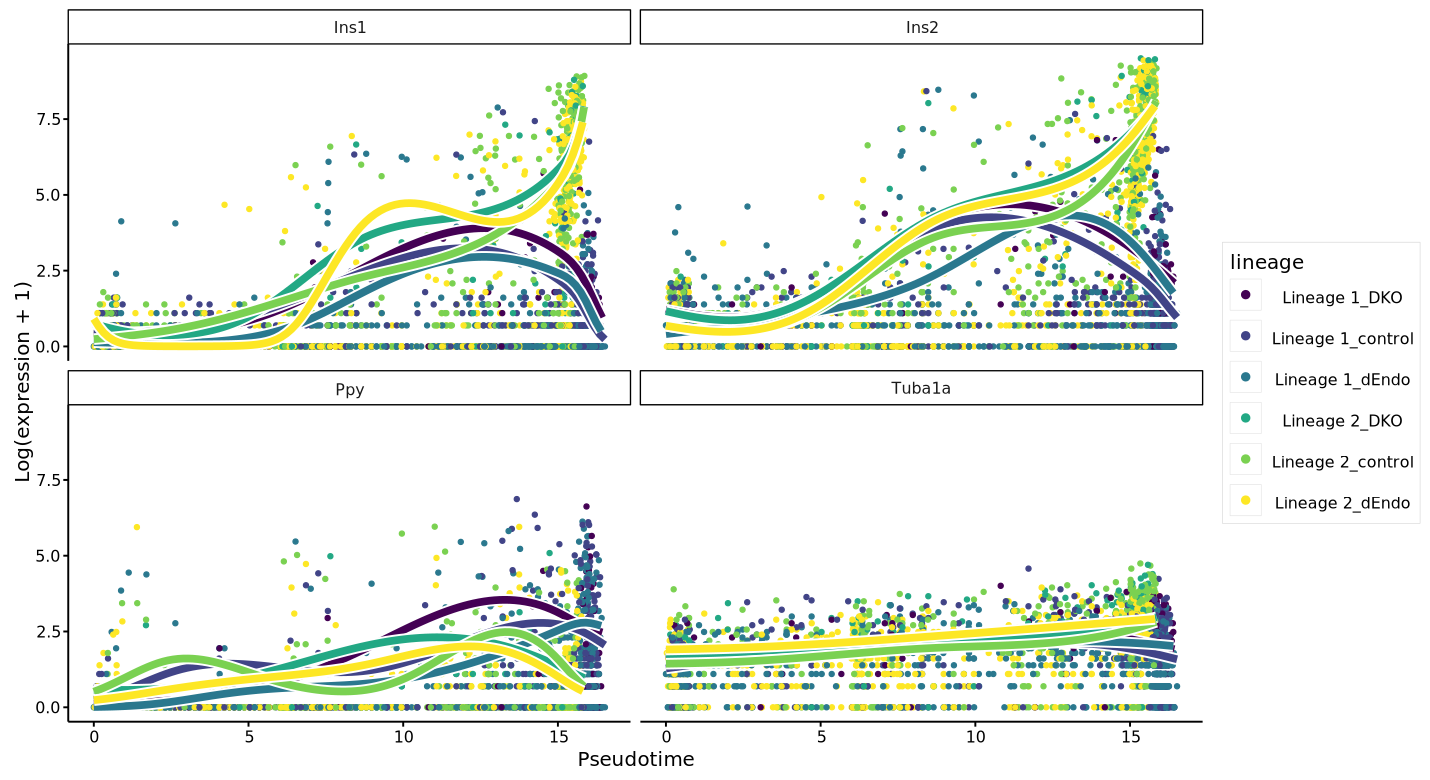

condition smoother genes: ['Ins1', 'Ins2', 'Ppy', 'Tuba1a']


In [14]:
cond_panel = list(dict.fromkeys([g for g in patt.index[:400]] + markers))
cond_panel = [g for g in cond_panel if g in set(main_panel)][:TS_COND_PANEL]
subc = subm.copy()
ts.fit_gam(subc, genes=cond_panel, n_knots=N_KNOTS, conditions_key="geno_short",
           parallel=True, n_jobs=CORES, verbose=False)
cond = ts.condition_test(subc, lineages=True).sort_values("waldStat", ascending=False)
cond.to_csv(f"{OUTDIR}/tradeseq_condition_test.csv")
nsig = int((cond["pvalue"] < 0.05).sum())
print(f"conditionTest: {nsig}/{len(cond)} genes with genotype-dependent dynamics (p<0.05)")
print(cond.head(15)[["waldStat","pvalue"]].to_string())
show_genes = list(dict.fromkeys(
    [g for g in cond.index if g in set(markers)][:2] + list(cond.index[:4])))[:4]  # markers first
try:
    pc = ts.plot_smoothers(subc, gene=show_genes)   # curves split by genotype within each lineage
    gg.ggsave(f"{FIGDIR}/tradeseq_condition_smoothers.png", pc, width=11, height=6, dpi=130)
    show(f"{FIGDIR}/tradeseq_condition_smoothers.png")
    print("condition smoother genes:", show_genes)
except Exception as e:
    print("condition smoothers failed:", repr(e))

## 12. Summary

- A supervised Monocle2/DDRTree trajectory resolves a **progenitor → *Fev*⁺ precursor → {alpha, beta}** bifurcation rooted at the *Neurog3*-high progenitor.
- Per-arm marker programs, BEAM, and tradeSeq all confirm the two arms carry the canonical alpha (*Gcg/Arx/Irx1/2/Ttr*) and beta (*Ins1/2/Iapp/Mafa/Slc2a2/Ucn3*) programs.
- **Arm allocation does not differ significantly across genotypes at the embryo level** (Kruskal-Wallis), consistent with the published conclusion that E15.5 cell allocation is largely unperturbed; the condition-aware tradeSeq quantifies where, along pseudotime, dynamics shift by genotype.

See `report.md` for interpretation, limitations, and follow-ups.